# CineMatch Movie Recommendation Engine - Model Training & Evaluation

This notebook builds the hybrid recommendation engine for CineMatch by combining content-based filtering (TF-IDF over genres/tags) and collaborative filtering (TruncatedSVD over user ratings).

### Pipeline Overview:
1. **Data Loading & Preprocessing**: Clean duplicates, extract release years, and aggregate movie tags.
2. **Exploratory Data Analysis (EDA)**: Analyze and visualize genre and year distributions.
3. **Content-Based Model**: Build a TF-IDF matrix of movie genres and tags, enabling on-demand cosine similarity queries.
4. **Collaborative Filtering**: Construct a sparse user-item matrix, center the ratings by user means, and perform TruncatedSVD dimensionality reduction.
5. **Hybrid Routing & Testing**: Evaluate model metrics (RMSE/MAE) and inspect qualitative recommendation queries.


In [1]:
import os
import re
import pickle
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import TruncatedSVD
from sklearn.model_selection import train_test_split
from scipy.sparse import csr_matrix

BASE_DIR = os.path.dirname(os.path.dirname(os.path.abspath("__file__")))
DATA_DIR = os.path.join(BASE_DIR, "data")
MODEL_DIR = os.path.join(BASE_DIR, "model")
PLOT_DIR = os.path.join(MODEL_DIR, "plots")
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(PLOT_DIR, exist_ok=True)

print("Environment configured. Base directory:", BASE_DIR)


Environment configured. Base directory: d:\temp\Movie Recommendation System



In [2]:
print("PHASE 1: Data Loading & Cleaning")
movies = pd.read_csv(os.path.join(DATA_DIR, "movies.csv"))
ratings = pd.read_csv(os.path.join(DATA_DIR, "ratings.csv"))
tags = pd.read_csv(os.path.join(DATA_DIR, "tags.csv"))
links = pd.read_csv(os.path.join(DATA_DIR, "links.csv"))

# Deduplicate
for name, df in [("movies", movies), ("ratings", ratings), ("tags", tags), ("links", links)]:
    df.drop_duplicates(inplace=True)

# Parse genres
movies["genres_list"] = movies["genres"].apply(
    lambda g: g.split("|") if g != "(no genres listed)" else []
)

def extract_year(title):
    match = re.search(r"\((\d{4})\)\s*$", title)
    return int(match.group(1)) if match else None

def clean_title(title):
    return re.sub(r"\s*\(\d{4}\)\s*$", "", title).strip()

movies["year"] = movies["title"].apply(extract_year)
movies["clean_title"] = movies["title"].apply(clean_title)

# Aggregate tags per movie
tags["tag"] = tags["tag"].astype(str).str.lower().str.strip()
tags_agg = (
    tags.groupby("movieId")["tag"]
    .apply(lambda x: " ".join(sorted(set(x))))
    .reset_index()
    .rename(columns={"tag": "tags_text"})
)
movies = movies.merge(tags_agg, on="movieId", how="left")
movies["tags_text"] = movies["tags_text"].fillna("")

# Construct IMDb links mapping
links["imdbId"] = links["imdbId"].apply(lambda x: f"tt{int(x):07d}" if pd.notna(x) else None)
imdb_map = dict(zip(links["movieId"], links["imdbId"]))

# Display catalog dimensions and preview
print(f"Loaded {len(movies)} movies, {len(ratings)} user ratings, {len(tags)} tags.")
print("\nMovies dataset preview:")
print(movies[["movieId", "title", "genres", "year"]].head(5).to_string(index=False))


PHASE 1: Data Loading & Cleaning
Loaded 9742 movies, 100836 user ratings, 3683 tags.

Movies dataset preview:
 movieId                              title                                      genres   year
       1                   Toy Story (1995) Adventure|Animation|Children|Comedy|Fantasy 1995.0
       2                     Jumanji (1995)                  Adventure|Children|Fantasy 1995.0
       3            Grumpier Old Men (1995)                              Comedy|Romance 1995.0
       4           Waiting to Exhale (1995)                        Comedy|Drama|Romance 1995.0
       5 Father of the Bride Part II (1995)                                      Comedy 1995.0



PHASE 2: Exploratory Data Analysis
Top 10 genres in the catalog:
    Genre  Count
    Drama   4361
   Comedy   3756
 Thriller   1894
   Action   1828
  Romance   1596
Adventure   1263
    Crime   1199
   Sci-Fi    980
   Horror    978
  Fantasy    779

Movie release years span from 1902 to 2018.



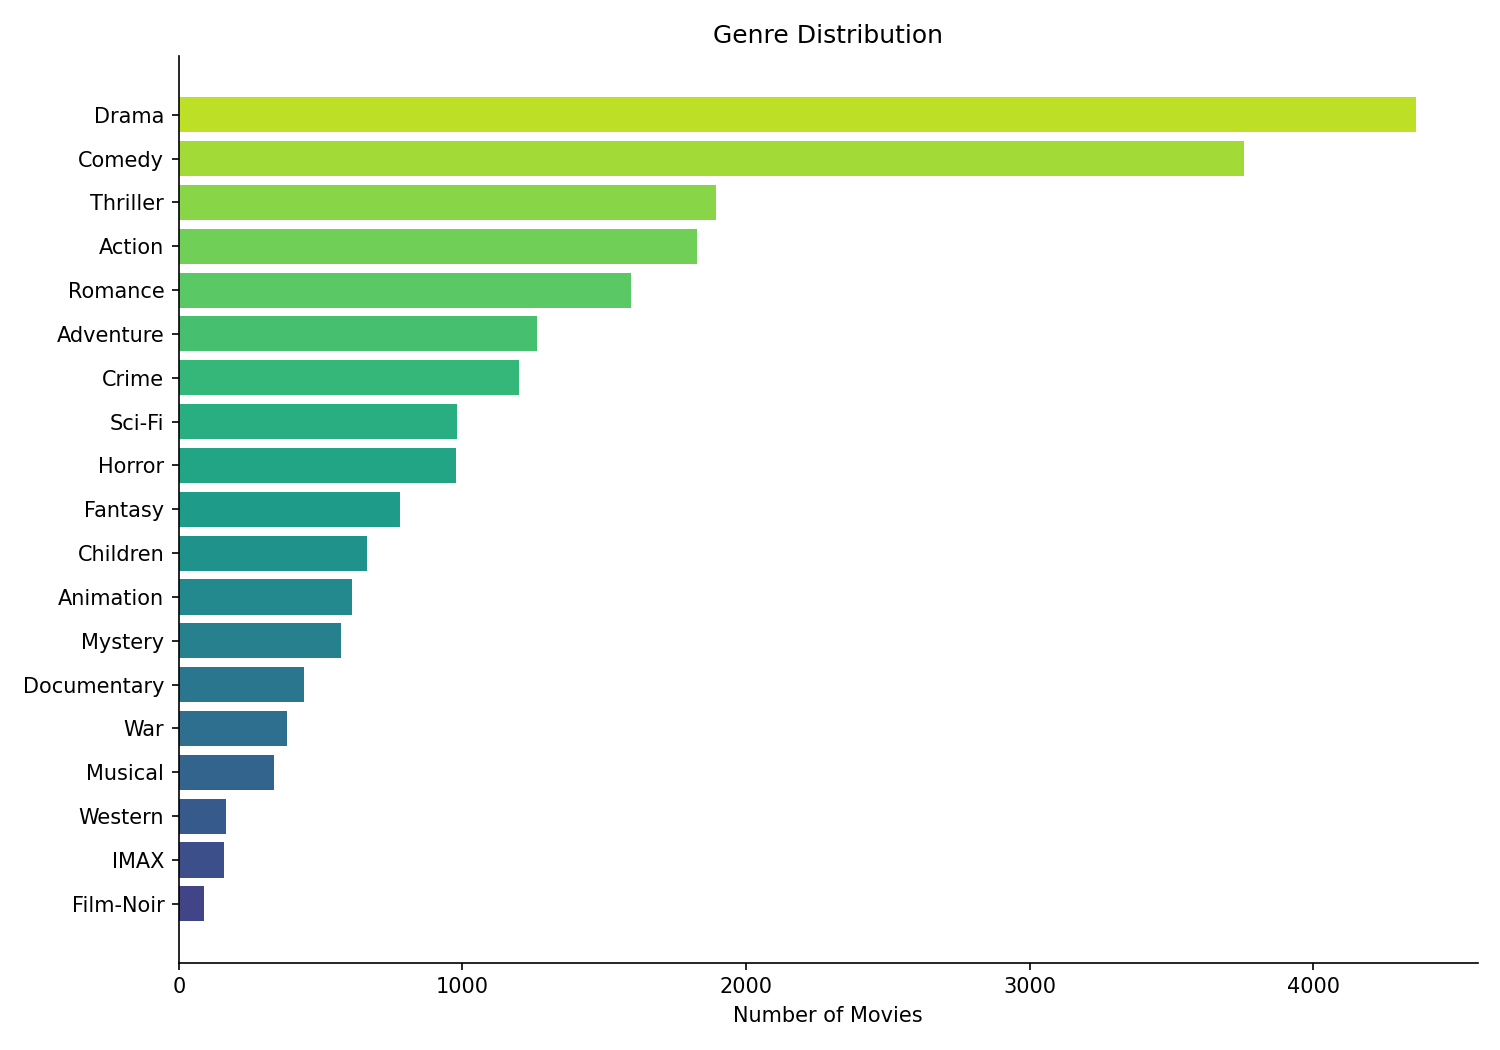

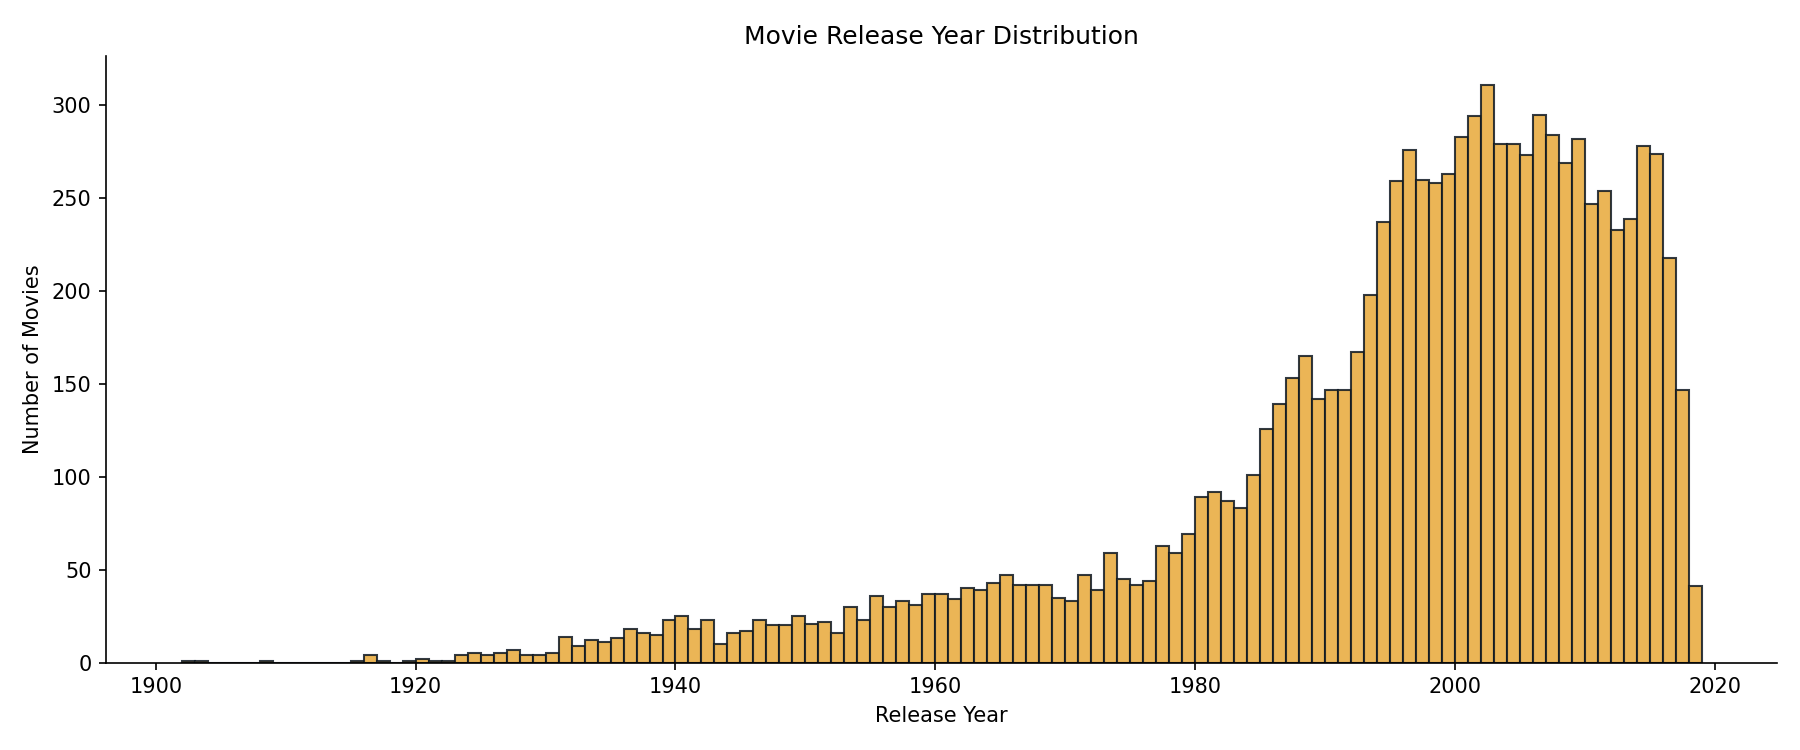

In [3]:
print("PHASE 2: Exploratory Data Analysis")
all_genres = [g for glist in movies["genres_list"] for g in glist]
genre_counts = Counter(all_genres)
genre_df = pd.DataFrame(genre_counts.items(), columns=["Genre", "Count"]).sort_values("Count", ascending=True)

print("Top 10 genres in the catalog:")
print(genre_df.tail(10)[::-1].to_string(index=False))

# Plot Genre distribution
fig, ax = plt.subplots(figsize=(10, 7))
colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(genre_df)))
ax.barh(genre_df["Genre"], genre_df["Count"], color=colors)
ax.set_xlabel("Number of Movies")
ax.set_title("Genre Distribution")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "genre_distribution.png"), dpi=150)
plt.close()

# Plot Year distribution
year_data = movies["year"].dropna().astype(int)
print(f"\nMovie release years span from {year_data.min()} to {year_data.max()}.")

fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(year_data, bins=range(year_data.min(), year_data.max() + 2), color="#e8a838", edgecolor="#0f1923", alpha=0.85)
ax.set_xlabel("Release Year")
ax.set_ylabel("Number of Movies")
ax.set_title("Movie Release Year Distribution")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "year_distribution.png"), dpi=150)
plt.close()

ratings_per_movie = ratings.groupby("movieId").size()


In [4]:
print("PHASE 3: Content-Based Model (TF-IDF)")
movies["content_text"] = movies["genres_list"].apply(lambda g: " ".join(g).lower()) + " " + movies["tags_text"]
movies["content_text"] = movies["content_text"].str.strip()

tfidf = TfidfVectorizer(
    max_features=5000,
    stop_words="english",
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
)
tfidf_matrix = tfidf.fit_transform(movies["content_text"])

print(f"Constructed TF-IDF feature matrix with shape: {tfidf_matrix.shape}")

# Compute per-movie rating statistics from ratings.csv
avg_ratings = ratings.groupby("movieId")["rating"].mean()
rating_counts = ratings.groupby("movieId")["rating"].count()
print(f"Computed average ratings for {len(avg_ratings)} movies.")

movie_lookup = {}
id_to_idx = {}
for idx, row in movies.iterrows():
    mid = int(row["movieId"])
    movie_lookup[mid] = {
        "title": row["title"],
        "clean_title": row["clean_title"],
        "genres": row["genres"],
        "year": int(row["year"]) if pd.notna(row["year"]) else None,
        "imdb_id": imdb_map.get(mid),
        "avg_rating": round(float(avg_ratings.get(mid, 0)), 2),
        "rating_count": int(rating_counts.get(mid, 0)),
        "idx": idx,
    }
    id_to_idx[mid] = idx

with open(os.path.join(MODEL_DIR, "tfidf_vectorizer.pkl"), "wb") as f:
    pickle.dump(tfidf, f)
with open(os.path.join(MODEL_DIR, "movie_feature_vectors.pkl"), "wb") as f:
    pickle.dump(tfidf_matrix, f)
with open(os.path.join(MODEL_DIR, "movie_lookup.pkl"), "wb") as f:
    pickle.dump(movie_lookup, f)
with open(os.path.join(MODEL_DIR, "id_to_idx.pkl"), "wb") as f:
    pickle.dump(id_to_idx, f)

print("Saved TF-IDF models and metadata lookup dictionary to disk.")


PHASE 3: Content-Based Model (TF-IDF)
Constructed TF-IDF feature matrix with shape: (9742, 1437)
Computed average ratings for 9724 movies.
Saved TF-IDF models and metadata lookup dictionary to disk.



In [5]:
print("PHASE 4: Collaborative Filtering (TruncatedSVD)")

train_ratings, test_ratings = train_test_split(
    ratings, test_size=0.2, random_state=42
)

all_user_ids = sorted(ratings["userId"].unique())
all_movie_ids = sorted(ratings["movieId"].unique())
user_id_map = {uid: i for i, uid in enumerate(all_user_ids)}
movie_id_map = {mid: i for i, mid in enumerate(all_movie_ids)}

n_users = len(all_user_ids)
n_movies = len(all_movie_ids)
print(f"User-Item Interaction Dimensions: {n_users} users x {n_movies} movies")

row_indices = train_ratings["userId"].map(user_id_map).values
col_indices = train_ratings["movieId"].map(movie_id_map).values
values = train_ratings["rating"].values

user_item_matrix = csr_matrix(
    (values, (row_indices, col_indices)),
    shape=(n_users, n_movies),
)

user_rating_sums = np.array(user_item_matrix.sum(axis=1)).flatten()
user_rating_counts = np.array((user_item_matrix != 0).sum(axis=1)).flatten()
user_means = np.divide(
    user_rating_sums, user_rating_counts,
    out=np.zeros_like(user_rating_sums, dtype=float),
    where=user_rating_counts != 0,
)

# Mean centering user ratings to handle individual rating biases
user_item_centered = user_item_matrix.copy().astype(float)
for i in range(n_users):
    start, end = user_item_centered.indptr[i], user_item_centered.indptr[i + 1]
    user_item_centered.data[start:end] -= user_means[i]

N_COMPONENTS = 50
svd = TruncatedSVD(n_components=N_COMPONENTS, random_state=42)
user_factors = svd.fit_transform(user_item_centered)
item_factors = svd.components_.T

print(f"Decomposed item factor matrix shape: {item_factors.shape}")

# Evaluate predictions on testing set
test_predictions = []
test_actuals = []
skipped = 0

for _, row in test_ratings.iterrows():
    uid = row["userId"]
    mid = row["movieId"]
    if uid in user_id_map and mid in movie_id_map:
        u_idx = user_id_map[uid]
        m_idx = movie_id_map[mid]
        pred = user_means[u_idx] + np.dot(user_factors[u_idx], item_factors[m_idx])
        pred = np.clip(pred, 0.5, 5.0)
        test_predictions.append(pred)
        test_actuals.append(row["rating"])
    else:
        skipped += 1

test_predictions = np.array(test_predictions)
test_actuals = np.array(test_actuals)
rmse = np.sqrt(np.mean((test_predictions - test_actuals) ** 2))
mae = np.mean(np.abs(test_predictions - test_actuals))

print(f"Collaborative Model Evaluation Metrics:")
print(f"  Test RMSE: {rmse:.4f}")
print(f"  Test MAE:  {mae:.4f}")
print(f"  Cold-start entries skipped: {skipped}")

COLLAB_MIN_RATINGS = 20
movies_with_enough = (ratings_per_movie >= COLLAB_MIN_RATINGS).sum()
print(f"Movies with >= {COLLAB_MIN_RATINGS} ratings (eligible for collaborative routing): {movies_with_enough}")

collab_artifacts = {
    "svd_model": svd,
    "user_factors": user_factors,
    "item_factors": item_factors,
    "user_means": user_means,
    "user_id_map": user_id_map,
    "movie_id_map": movie_id_map,
    "ratings_per_movie": ratings_per_movie.to_dict(),
    "collab_min_ratings": COLLAB_MIN_RATINGS,
}
with open(os.path.join(MODEL_DIR, "collab_model.pkl"), "wb") as f:
    pickle.dump(collab_artifacts, f)

metrics = {
    "rmse": float(rmse),
    "mae": float(mae),
    "n_components": N_COMPONENTS,
    "explained_variance": float(svd.explained_variance_ratio_.sum()),
    "train_size": len(train_ratings),
    "test_size": len(test_ratings),
    "cold_start_skipped": skipped,
    "collab_min_ratings": COLLAB_MIN_RATINGS,
    "eligible_movies": int(movies_with_enough),
}
with open(os.path.join(MODEL_DIR, "metrics.pkl"), "wb") as f:
    pickle.dump(metrics, f)

print("Saved Collaborative models and parameters to disk.")


PHASE 4: Collaborative Filtering (TruncatedSVD)
User-Item Interaction Dimensions: 610 users x 9724 movies
Decomposed item factor matrix shape: (9724, 50)
Collaborative Model Evaluation Metrics:
  Test RMSE: 0.9320
  Test MAE:  0.7193
  Cold-start entries skipped: 0
Movies with >= 20 ratings (eligible for collaborative routing): 1297
Saved Collaborative models and parameters to disk.



In [6]:
print("PHASE 5: Qualitative Evaluation - Recommendations Test Suite")

def get_content_recommendations(movie_id, top_n=10):
    if movie_id not in movie_lookup:
        return []
    idx = movie_lookup[movie_id]["idx"]
    query_vec = tfidf_matrix[idx:idx+1]
    sim_scores = cosine_similarity(query_vec, tfidf_matrix).flatten()
    sim_scores[idx] = -1
    top_indices = sim_scores.argsort()[::-1][:top_n]
    results = []
    for i in top_indices:
        mid = movies.iloc[i]["movieId"]
        results.append({
            "movie_id": int(mid),
            "title": movie_lookup[int(mid)]["title"],
            "genres": movie_lookup[int(mid)]["genres"],
            "similarity": float(sim_scores[i]),
        })
    return results

test_movies = {
    "The Dark Knight (2008) - Action/Thriller": 79132,
    "Toy Story (1995) - Animation/Family": 1,
    "The Shining (1980) - Horror": 1258,
    "Pulp Fiction (1994) - Crime/Drama": 296,
    "The Grand Budapest Hotel (2014) - Comedy/Drama": 116797,
    "The Matrix (1999) - Sci-Fi/Action": 2571,
}

for label, movie_id in test_movies.items():
    if movie_id not in movie_lookup:
        print(f"Movie ID {movie_id} ({label}) not in catalog, skipping.")
        continue

    info = movie_lookup[movie_id]
    print(f"\nQuery: {info['title']} [{info['genres']}]")
    recs = get_content_recommendations(movie_id, top_n=5)
    for i, rec in enumerate(recs, 1):
        print(f"  {i}. {rec['title']} [{rec['genres']}] (sim: {rec['similarity']:.3f})")

print("\nTRAINING PIPELINE COMPLETE")


PHASE 5: Qualitative Evaluation - Recommendations Test Suite

Query: Inception (2010) [Action|Crime|Drama|Mystery|Sci-Fi|Thriller|IMAX]
  1. Donnie Darko (2001) [Drama|Mystery|Sci-Fi|Thriller] (sim: 0.344)
  2. Arrival (2016) [Sci-Fi] (sim: 0.309)
  3. Strange Days (1995) [Action|Crime|Drama|Mystery|Sci-Fi|Thriller] (sim: 0.309)
  4. Watchmen (2009) [Action|Drama|Mystery|Sci-Fi|Thriller|IMAX] (sim: 0.307)
  5. Super 8 (2011) [Mystery|Sci-Fi|Thriller|IMAX] (sim: 0.295)

Query: Toy Story (1995) [Adventure|Animation|Children|Comedy|Fantasy]
  1. Bug's Life, A (1998) [Adventure|Animation|Children|Comedy] (sim: 0.794)
  2. Moana (2016) [Adventure|Animation|Children|Comedy|Fantasy] (sim: 0.700)
  3. Asterix and the Vikings (Astérix et les Vikings) (2006) [Adventure|Animation|Children|Comedy|Fantasy] (sim: 0.700)
  4. Monsters, Inc. (2001) [Adventure|Animation|Children|Comedy|Fantasy] (sim: 0.700)
  5. The Good Dinosaur (2015) [Adventure|Animation|Children|Comedy|Fantasy] (sim: 0.700)

Query: